In [ ]:
#| hide
#| default_exp shell

# shell

> A shell for running notebook code without a notebook server

In [ ]:
#| export
from fastcore.utils import *
from fastcore.meta import delegates
from fastcore.script import call_parse
from fastcore.ansi import strip_ansi

import multiprocessing,types,traceback,signal,builtins
from contextlib import contextmanager
try:
    if sys.platform == 'darwin': multiprocessing.set_start_method("fork")
except RuntimeError: pass # if re-running cell

from traitlets.config import Config
from traitlets.config.loader import PyFileConfigLoader
from IPython.paths import get_ipython_dir
from IPython.core.interactiveshell import InteractiveShell, ExecutionInfo, ExecutionResult
from IPython.core.error import UsageError, StdinNotImplementedError
from IPython.core.displayhook import DisplayHook
from IPython.utils.capture import capture_output
from IPython.core.completer import IPCompleter,provisionalcompleter
from IPython.core.hooks import CommandChainDispatcher
from IPython.core.completerlib import module_completer
from IPython.utils.strdispatch import StrDispatch

from base64 import b64encode
from html import escape

from fastcore.nbio import *
from fastcore.nbio import _dict2obj

In [ ]:
from fastcore.ansi import ansi2html
from IPython.display import HTML
from fastcore.test import *
from base64 import b64decode
from io import BytesIO
from PIL import Image
import tempfile
from contextlib import contextmanager

## CaptureShell -

In [ ]:
#| export
class _CustDisplayHook(DisplayHook):
    def write_output_prompt(self): pass
    def write_format_data(self, data, md_dict): pass
    def log_output(self, format_dict): pass

@patch
def __repr__(self: ExecutionInfo): return f'cell: {self.raw_cell}; id: {self.cell_id}'

@patch
def __repr__(self: ExecutionResult): return f'result: {self.result}; err: {self.error_in_exec}; info: <{self.info}>'

In [ ]:
#| export
def _profile_cfg(name='default'):
    "Merged config, extensions, and profile dir for IPython profile `name`"
    pd = Path(get_ipython_dir())/f'profile_{name}'
    cfg,exts = Config(),[]
    for f in ('ipython_config.py','ipython_kernel_config.py'):
        if not (pd/f).exists(): continue
        c = PyFileConfigLoader(f, path=str(pd)).load_config()
        e = c.get('InteractiveShellApp', {}).get('extensions', [])
        exts += e.get_value([]) if hasattr(e, 'get_value') else e
        cfg.merge(c)
    return cfg,exts,pd

In [ ]:
#| export
def leading_comment_lines(lines):
    "Input cleanup transform: drop leading blank/comment lines when the first code line is a cell magic, which IPython otherwise misparses as a line magic"
    i = next((i for i,l in enumerate(lines) if l.strip() and not l.lstrip().startswith('#')), 0)
    return lines[i:] if i and lines[i].startswith('%%') else lines

In [ ]:
s = InteractiveShell()

In [ ]:
#| export
class CaptureShell(InteractiveShell):
    displayhook_class = _CustDisplayHook
    _nested = False

    def __init__(self, path:str|Path=None, mpl_format='retina', history=False, timeout:Optional[int]=None, profile:bool=False):
        cfg = _profile_cfg()[0] if profile else Config()
        if not history: cfg.HistoryManager.hist_file = ':memory:'
        super().__init__(config=cfg)
        self.input_transformers_cleanup.append(leading_comment_lines)
        self.history_manager.enabled = history
        self.timeout = timeout
        self.result,self.exc,self._cell_idx,self._fname = None,None,None,None
        if path: self.set_path(path)
        self.display_formatter.active = True
        if not in_notebook(): InteractiveShell._instance = self
        if mpl_format:
            try: from matplotlib_inline.backend_inline import set_matplotlib_formats
            except ImportError: set_matplotlib_formats = None
            if set_matplotlib_formats:
                self.enable_matplotlib("inline")
                self._run("from matplotlib_inline.backend_inline import set_matplotlib_formats")
                self._run(f"set_matplotlib_formats('{mpl_format}')")
        if profile: self.load_profile()

    def set_path(self, path):
        "Add `path` to python path, or `path.parent` if it's a file"
        path = Path(path)
        if path.is_file(): path = path.parent
        self._run(f"import sys\nif '{path.as_posix()}' not in sys.path: sys.path.insert(0, '{path.as_posix()}')")

    def enable_gui(self, gui=None): pass

Captured execution is factored into three pieces. `_captured` wraps a run with output capture, stdin blocking, and the optional SIGALRM timeout. `_run_res` packages the result and captured streams as the `AttrDict` that rendering uses. The run call itself comes in two forms sharing those pieces: `_run_async` awaits `fastcore.nbio.run_cell` on the calling loop, and is the path everything public uses, while sync `_run` goes through IPython's own `run_cell` entry, for constructor-time setup lines that run before any loop exists.


In [ ]:
#| export
def _no_stdin(*args, **kw): raise StdinNotImplementedError('input() is not supported in a captured run')

@patch
@contextmanager
def _captured(self:CaptureShell, stdout=True, stderr=True, display=True, timeout=None, verbose=False):
    "Output capture, stdin blocking, and optional SIGALRM timeout around one cell run"
    if not timeout: timeout = self.timeout
    prev_alarm = None
    if timeout:
        def handler(*args): raise TimeoutError()
        prev_alarm = signal.signal(signal.SIGALRM, handler)
        signal.alarm(timeout)
    prev_input = builtins.input
    builtins.input = _no_stdin
    try:
        with capture_output(display=display, stdout=stdout and not verbose, stderr=stderr and not verbose) as c: yield c
    finally:
        builtins.input = prev_input
        if timeout:
            signal.alarm(0)
            signal.signal(signal.SIGALRM, prev_alarm)

In [ ]:
#| export
@patch
def _run_res(self:CaptureShell, result, c):
    "Package a cell `result` and its captured output `c` as the `AttrDict` rendering uses"
    e = result.error_in_exec or result.error_before_exec
    if isinstance(e, UsageError) and str(e).startswith('Line magic function `%%'):
        e.args = (f"{e} A cell magic (%%) must start the cell; remove or move the lines above it.",)
    return AttrDict(result=result, stdout=c.stdout, stderr=c.stderr, display_objects=c.outputs, exception=e)

In [ ]:
#| export
@patch
def _run(self:CaptureShell, raw_cell, store_history=False, silent=False, shell_futures=True, cell_id=None,
    stdout=True, stderr=True, display=True, timeout=None, verbose=False):
    "Sync captured run through IPython's own `run_cell` entry, for constructor-time setup lines that run before any loop exists"
    with self._captured(stdout, stderr, display, timeout, verbose) as c:
        result = super(CaptureShell, self).run_cell(raw_cell, store_history, silent, shell_futures=shell_futures, cell_id=cell_id)
    return self._run_res(result, c)

In [ ]:
#| export
@patch
async def _run_async(self:CaptureShell, raw_cell, store_history=False, silent=False, shell_futures=True, cell_id=None,
    stdout=True, stderr=True, display=True, timeout=None, verbose=False):
    "Async `_run`: awaits the cell via `fastcore.nbio.run_cell` on the calling loop, so `raw_cell` may use top-level `await`"
    with self._captured(stdout, stderr, display, timeout, verbose) as c:
        result = await run_cell(self, raw_cell, store_history, silent, shell_futures=shell_futures, cell_id=cell_id)
    return self._run_res(result, c)


In [ ]:
#| export
@patch
def load_profile(self:CaptureShell, name='default'):
    "Load profile `name`'s extensions and run its startup files (output suppressed), as `ipykernel` does"
    cfg,exts,pd = _profile_cfg(name)
    warns = []
    with capture_output():
        for o in exts:
            try: self.extension_manager.load_extension(o)
            except Exception as e: warns.append(f"Failed loading extension {o}: {e}")
        sd = pd/'startup'
        for f in sorted([*sd.glob('*.py'), *sd.glob('*.ipy')]) if sd.is_dir() else []:
            try:
                if f.suffix=='.ipy': self.safe_execfile_ipy(f, raise_exceptions=True)
                else: self.safe_execfile(f, self.user_ns, raise_exceptions=True)
            except Exception as e: warns.append(f"Failed running startup file {f}: {e}")
    for w in warns: warnings.warn(w)

`profile=True` makes a `CaptureShell` behave like `ipykernel` at startup: it reads the IPython profile (honoring `IPYTHONDIR`), applies shell config traits from `ipython_config.py` and `ipython_kernel_config.py`, loads their `InteractiveShellApp.extensions`, and runs the profile's `startup` files. (`exec_lines`/`exec_files` are not run.)

To demo profile loading we need a temporary IPython profile:

In [ ]:
@contextmanager
def _tmp_profile(cfg='', kcfg='', startup=''):
    with tempfile.TemporaryDirectory() as td, modified_env(IPYTHONDIR=td):
        pd = Path(td)/'profile_default'
        (pd/'startup').mkdir(parents=True)
        if cfg: (pd/'ipython_config.py').write_text(cfg)
        if kcfg: (pd/'ipython_kernel_config.py').write_text(kcfg)
        if startup: (pd/'startup'/'00-start.py').write_text(startup)
        yield td

Startup files in the profile's `startup` directory are run, so their variables appear in the shell's namespace:

In [ ]:
with _tmp_profile(startup="a=7\n"): test_eq(CaptureShell(profile=True).user_ns['a'], 7)

Extensions and startup files often print or display things as they load; `load_profile` suppresses that output so it can't leak into test runs or captured results (failures still surface as warnings):

In [ ]:
with _tmp_profile(startup="b=1\nprint('starting up')\n"):
    with capture_output() as cap: sp = CaptureShell(profile=True)
test_eq((cap.stdout, sp.user_ns['b']), ('', 1))

Shell config traits from the profile's config files are applied too:

In [ ]:
with _tmp_profile(kcfg="c.InteractiveShell.ast_node_interactivity='all'\n"):
    test_eq(CaptureShell(profile=True).ast_node_interactivity, 'all')

With the default `history=False`, the shell's history database lives in memory, so creating shells never writes a `history.sqlite` into the profile directory:

In [ ]:
with _tmp_profile() as td:
    CaptureShell(profile=True)
    test_eq((Path(td)/'profile_default'/'history.sqlite').exists(), False)

In [ ]:
#| hide
with _tmp_profile(cfg="c.InteractiveShellApp.extensions.append('_ext_a')\n",
                  kcfg="c.InteractiveShellApp.extensions.append('_ext_b')\n") as td:
    for m in ('_ext_a','_ext_b'): (Path(td)/f"{m}.py").write_text(f"def load_ipython_extension(ip): ip.user_ns['{m}'] = 1\n")
    try:
        sp = CaptureShell(path=td, profile=True)
        test_eq((sp.user_ns['_ext_a'], sp.user_ns['_ext_b']), (1, 1))
    finally:
        if td in sys.path: sys.path.remove(td)
        for m in ('_ext_a','_ext_b'): sys.modules.pop(m, None)

### Cells / run

In [ ]:
#| export
def format_exc(e):
    "Format exception `e` as a string list"
    return traceback.format_exception(type(e), e, e.__traceback__)

In [ ]:
#| export
class NbResult(list): pass

In [ ]:
#| export
def _out_stream(text, name): return mk_stream(name, text.splitlines(True))
def _out_exc(e): return mk_error(format_exc(e), ename=type(e).__name__, evalue=str(e))

def _format_mimedata(k, v):
    "Format mime-type keyed data consistently with Jupyter"
    if k.startswith('text/'): return v.splitlines(True)
    if k.startswith('image/') and isinstance(v, bytes):
        v = b64encode(v).decode()
        return v+'\n' if not v.endswith('\n') else v
    return v

def _mk_out(data, meta, output_type='display_data'):
    fd = {k:_format_mimedata(k,v) for k,v in data.items()}
    return dict(data=fd, metadata=meta, output_type=output_type)

def _out_nb(o, fmt):
    res = NbResult()
    if o.stdout: res.append(_out_stream(o.stdout, 'stdout'))
    if o.stderr: res.append(_out_stream(o.stderr, 'stderr'))
    if o.exception: res.append(_out_exc(o.exception))
    res.result = o.result.result
    for x in o.display_objects: res.append(_mk_out(x.data, x.metadata))
    if res.result is not None: res.append(_mk_out(*fmt.format(res.result), 'execute_result'))
    for p in res:
        if p["output_type"]=="execute_result": p['execution_count'] = o.result.execution_count
    return res

In [ ]:
#| export
@patch
async def run(
    self:CaptureShell,
    code:str, # Python/IPython code to run
    stdout=True, # Capture stdout and save as output?
    stderr=True, # Capture stderr and save as output?
    timeout:Optional[int]=None, # Shell command will time out after {timeout} seconds
    verbose:bool=False # Show stdout/stderr during execution
):
    "Run `code`, returning a list of all outputs in Jupyter notebook format"
    res = await self._run_async(code, store_history=True, stdout=stdout, stderr=stderr, timeout=timeout, verbose=verbose)
    self.result = res.result.result
    self.exc = res.exception
    return _out_nb(res, self.display_formatter)

Captured runs pass `store_history=True`, so IPython's own trailing-`;` suppression applies, and the check is tokenizer-based: a comment after the `;` still suppresses. A cell magic's payload is unaffected, since its transformed source ends in the `run_cell_magic(...)` call rather than a semicolon. That is the right behavior for payloads, which may be shell code, markup, or another language where a trailing `;` means nothing. A suppressed result is never populated, so no `execute_result` output appears. Streams are unaffected either way:


In [ ]:
cs = CaptureShell(mpl_format=None)
cs.register_magic_function(lambda line, cell: 'visible', 'cell', 'visible')
res = await cs.run("%%visible\npayload;")
test_eq(res[0]['data']['text/plain'], ["'visible'"])
test_eq(await cs.run("1+1;"), [])
test_eq(await cs.run("print('kept'); 2;"), [dict(output_type='stream', name='stdout', text=['kept\n'])])


In [ ]:
s = CaptureShell()

In [ ]:
await s.run("print(1)")

[{'name': 'stdout', 'output_type': 'stream', 'text': ['1\n']}]

Code can include magics and `!` shell commands:

In [ ]:
o = await s.run("%time 1+1")
o

[{'name': 'stdout',
  'output_type': 'stream',
  'text': ['CPU times: user 1e+03 ns, sys: 0 ns, total: 1e+03 ns\n',
   'Wall time: 1.91 us\n']},
 {'data': {'text/plain': ['2']},
  'metadata': {},
  'output_type': 'execute_result',
  'execution_count': None}]

The result of the last successful execution is stored in `result`:

In [ ]:
s.result

2

A trailing `;` stops the result from being captured:

In [ ]:
await s.run("1+2;")

[]

Code running inside a cell can itself call `run_cell` (the `%%capture` magic does exactly that). Such nested calls behave exactly as in plain IPython. They return an `ExecutionResult`, and their output flows to the enclosing capture context, so `%%capture` works:


In [ ]:
await s.run("%%capture c\nprint(1)")
test_eq(s.user_ns['c'].stdout, '1\n')
await s.run("r = get_ipython().run_cell('7')")
test_eq(s.user_ns['r'].__class__.__name__, 'ExecutionResult')


IPython requires a cell magic to be the very first line of a cell: even a comment above it makes the `%%foo` line parse as a *line* magic named `%foo`, which fails with a confusing "Line magic function `%%foo` not found" error. `CaptureShell` smooths both edges: leading blank and comment lines above a cell magic are dropped (extending IPython's own `leading_empty_lines` cleanup), and when real code precedes the magic (which can't be auto-fixed), the error message explains the actual problem.

In [ ]:
await s.run('# a narration comment\n\n%%capture c2\nprint(2)')
test_eq(s.exc, None)
test_eq(s.user_ns['c2'].stdout, '2\n')


In [ ]:
await s.run('a=1\n%%capture c3\nprint(3)')
assert 'must start the cell' in str(s.exc)


In [ ]:
o = await s.run("1/0")
o

[{'name': 'stdout',
  'output_type': 'stream',
  'text': ['\x1b---------------------------------------------------------------------------\x1b\n',
   '\x1bZeroDivisionError\x1b                         Traceback (most recent call last)\n',
   '\x1bFile \x1b\x1b<ipython-input-1-9e1622b385b6>:1\x1b\n',
   '\x1b----> \x1b\x1b1\x1b \x1b1\x1b\x1b/\x1b\x1b0\x1b\n',
   '\n',
   '\x1bZeroDivisionError\x1b: division by zero\n']},
 {'ename': 'ZeroDivisionError',
  'evalue': 'division by zero',
  'output_type': 'error',
  'traceback': ['Traceback (most recent call last):\n',
   '  File "/Users/jhoward/aai-ws/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3748, in run_code\n    exec(code_obj, self.user_global_ns, self.user_ns)\n    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n',
   '  File "<ipython-input-1-9e1622b385b6>", line 1, in <module>\n    1/0\n    ~^~\n',
   'ZeroDivisionError: division by zero\n']}]

This is how IPython formats exceptions internally:

In [ ]:
from IPython.core.ultratb import VerboseTB

In [ ]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    formatter = VerboseTB(color_scheme='Linux')

In [ ]:
try: f()
except Exception as e:
    ex = e
    print(formatter.text(type(e), e, e.__traceback__))

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[58], line 4
      1 try: f()
      2 except Exception as e:
      3     ex = e
----> 4     print(formatter.text(type(e), e, e.__traceback__))

NameError: name 'f' is not defined


In [ ]:
await s.run("import time; time.sleep(0.1); print('no timeout')", timeout=1)

[{'name': 'stdout', 'output_type': 'stream', 'text': ['no timeout\n']}]

In [ ]:
o = await s.run("import time; time.sleep(1.1)", timeout=1)
o[0]['text'][:2]

['\x1b---------------------------------------------------------------------------\x1b\n',
 '\x1bTimeoutError\x1b                              Traceback (most recent call last)\n']

In [ ]:
o1 = await s.run('from IPython.display import Markdown,display; print(0); print(1); display(Markdown("*2*")); Markdown("*1*")')
o1

[{'name': 'stdout', 'output_type': 'stream', 'text': ['0\n', '1\n']},
 {'data': {'text/plain': ['Markdown(*2*)'], 'text/markdown': ['*2*']},
  'metadata': {},
  'output_type': 'display_data'},
 {'data': {'text/plain': ['Markdown(*1*)'], 'text/markdown': ['*1*']},
  'metadata': {},
  'output_type': 'execute_result',
  'execution_count': None}]

In [ ]:
oaw = render_text(await s.run("import asyncio\nawait asyncio.sleep(0.01)\n7"))
test_is('7' in oaw, True)

A captured run reports its exception structurally, packaged as an error output, so IPython's own traceback print would be a colored duplicate in the captured stream. `showtraceback` therefore does nothing.


In [ ]:
#| export
@patch
def showtraceback(self:CaptureShell, *args, **kwargs):
    "A captured run reports its exception structurally; IPython's printed traceback would be a colored duplicate in the stream"

@patch
def showsyntaxerror(self:CaptureShell, *args, **kwargs):
    "Like `showtraceback`"

An error cell yields exactly one output, the structural error, with no traceback text leaking into the stream:


In [ ]:
s = CaptureShell()
test_eq([x['output_type'] for x in await s.run('1/0')], ['error'])


In [ ]:
#| export
def _pre(s, xtra=''): return f"<pre {xtra}><code>{escape(s)}</code></pre>"
def _strip(s): return strip_ansi(escape(s))

def render_outputs(outputs, ansi_renderer=_strip, include_imgs=True, pygments=False, md_tfm=noop, html_tfm=noop):
    try:
        from mistletoe import markdown, HTMLRenderer
        from mistletoe.contrib.pygments_renderer import PygmentsRenderer
    except ImportError: return print('mistletoe not found -- please install it for execnb.shell.render_output')
    renderer = PygmentsRenderer if pygments else HTMLRenderer
    
    def render_output(out):
        otype = out['output_type']
        if otype == 'stream':
            txt = ansi_renderer(''.join(out["text"]))
            xtra = '' if out['name']=='stdout' else "class='stderr'"
            is_err = '<span class' in txt
            return f"<pre {xtra}><code class='{'nohighlight hljs' if is_err else ''}'>{txt}</code></pre>"
        elif otype in ('display_data','execute_result'):
            data = out['data']
            _g = lambda t: ''.join(data[t]) if t in data else None
            if d := _g('text/html'): return html_tfm(d)
            if d := _g('application/javascript'): return f'<script>{d}</script>'
            if d := _g('text/markdown'): return md_tfm(markdown(d, renderer=renderer))
            if d := _g('text/latex'): return f'<div class="math">${d}$</div>'
            if include_imgs:
                if d := _g('image/jpeg'): return f'<img src="data:image/jpeg;base64,{d}"/>'
                if d := _g('image/png'): return f'<img src="data:image/png;base64,{d}"/>'
                if d := _g('image/svg+xml'): return d
            if d := _g('text/plain'): return _pre(d)
            
        return ''

    return '\n'.join(map(render_output, outputs))

In [ ]:
HTML(render_outputs(o))

We can use `ansi2html` to convert from ANSI to HTML for color rendering.  You need some [css styles](https://github.com/fastai/fastcore/blob/master/examples/ansi.css) for the colors to render properly.  Jupyter already has these built in so it's not neccessary here, but if you plan on using this in another web app you will need to ensure that css styling is included.

In [ ]:
HTML(render_outputs(o, ansi2html))

Images and matplotlib figures are captured:


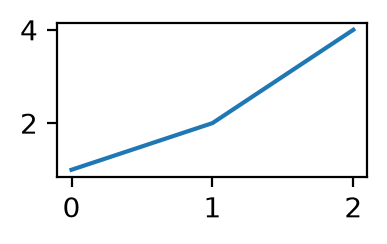

In [ ]:
res = await s.run('''import matplotlib.pyplot as plt
plt.figure(figsize=(2,1))
plt.plot([1,2,4]);''')

HTML(render_outputs(res))

If an exception is raised then the exception type, object, and stacktrace are stored in `exc`:

In [ ]:
o = await s.run('raise Exception("Oops")')
o

[{'name': 'stdout',
  'output_type': 'stream',
  'text': ['\x1b---------------------------------------------------------------------------\x1b\n',
   '\x1bException\x1b                                 Traceback (most recent call last)\n',
   '\x1bCell\x1b\x1b \x1b\x1bIn[1]\x1b\x1b, line 1\x1b\n',
   '\x1b----> \x1b\x1b1\x1b \x1braise\x1b \x1bException\x1b(\x1b"\x1b\x1bOops\x1b\x1b"\x1b)\n',
   '\n',
   '\x1bException\x1b: Oops\n']},
 {'ename': 'Exception',
  'evalue': 'Oops',
  'output_type': 'error',
  'traceback': ['Traceback (most recent call last):\n',
   '  File "/Users/jhoward/aai-ws/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3748, in run_code\n    exec(code_obj, self.user_global_ns, self.user_ns)\n    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n',
   '  File "<ipython-input-1-01648acb07bd>", line 1, in <module>\n    raise Exception("Oops")\n',
   'Exception: Oops\n']}]

In [ ]:
s.exc

Exception('Oops')

In [ ]:
#| export
@patch
async def cell(self:CaptureShell, cell, stdout=True, stderr=True, verbose=False):
    "Run `cell`, skipping if not code, and store outputs (and the execution count) back in cell"
    if cell.cell_type!='code': return
    self._cell_idx = cell.idx_ + 1
    outs = await self.run(cell.source, verbose=verbose)
    cell.outputs = _dict2obj(outs) if outs else []
    cell.execution_count = self.execution_count-1  # the count this run used: the shell has already advanced


In [ ]:
clean = Path('../tests/clean.ipynb')
nb = read_nb(clean)
c = nb.cells[1]
c

```python
{ 'cell_type': 'code',
  'execution_count': None,
  'id': 'b123d6d0',
  'idx_': 1,
  'metadata': {},
  'outputs': [],
  'source': 'print(1)\n2'}
```

In [ ]:
await s.cell(c)
c.outputs

[{'name': 'stdout', 'output_type': 'stream', 'text': ['1\n']},
 {'data': {'text/plain': ['2']},
  'metadata': {},
  'output_type': 'execute_result',
  'execution_count': None}]

Re-running a cell that no longer produces output clears its stale outputs:

In [ ]:
c2 = read_nb(clean).cells[1]
await s.cell(c2)
assert c2.outputs
c2.source = 'x = 1'
await s.cell(c2)
test_eq(c2.outputs, [])


In [ ]:
#| export
def find_output(
    outp, # Output from `run`
    ot='execute_result' # Output_type to find
):
    "Find first output of type `ot` in `CaptureShell.run` output"
    return first(o for o in outp if o['output_type']==ot)

In [ ]:
find_output(c.outputs)['data']

```python
{'text/plain': ['2']}
```

In [ ]:
find_output(c.outputs, 'stream')['text']

['1\n']

In [ ]:
#| export
def out_exec(outp):
    "Get data from execution result in `outp`."
    out = find_output(outp)
    if out: return '\n'.join(first(out['data'].values()))

In [ ]:
out_exec(c.outputs)

'2'

In [ ]:
#| export
def out_stream(outp):
    "Get text from stream in `outp`."
    out = find_output(outp, 'stream')
    if out: return ('\n'.join(out['text'])).strip()

In [ ]:
out_stream(c.outputs)

'1'

In [ ]:
#| export
def out_error(outp):
    "Get traceback from error in `outp`."
    out = find_output(outp, 'error')
    if out: return '\n'.join(out['traceback'])

### NBs

In [ ]:
#| export
def _false(o): return False

@patch
async def run_all(
    self:CaptureShell,
    nb, # A notebook read with `nbclient` or `read_nb`
    exc_stop:bool=False, # Stop on exceptions?
    preproc:callable=_false, # Called before each cell is executed
    postproc:callable=_false, # Called after each cell is executed
    inject_code:str|None=None, # Code to inject into a cell
    inject_idx:int=0, # Cell to replace with `inject_code`
    verbose:bool=False # Show stdout/stderr during execution
):
    "Run all cells in `nb`, stopping at first exception if `exc_stop`"
    if inject_code is not None: nb.cells[inject_idx].source = inject_code
    for cell in nb.cells:
        if not preproc(cell):
            await self.cell(cell, verbose=verbose)
            postproc(cell)
        if self.exc and exc_stop: raise self.exc from None

In [ ]:
nb.cells[2].outputs

[]

In [ ]:
await s.run_all(nb)
nb.cells[2].outputs

[{'data': {'text/plain': ['<IPython.core.display.Markdown object>'],
   'text/markdown': ["This is *bold*. Here's a [link](https://www.fast.ai)."]},
  'metadata': {},
  'output_type': 'execute_result',
  'execution_count': None}]

With `exc_stop=False` (the default), execution continues after exceptions, and exception details are stored into the appropriate cell's output:

In [ ]:
nb.cells[-1].source

'raise Exception("Oopsie!")'

In [ ]:
nb.cells[-1].outputs

[{'name': 'stdout',
  'output_type': 'stream',
  'text': ['\x1b---------------------------------------------------------------------------\x1b\n',
   '\x1bException\x1b                                 Traceback (most recent call last)\n',
   '\x1bCell\x1b\x1b \x1b\x1bIn[1]\x1b\x1b, line 1\x1b\n',
   '\x1b----> \x1b\x1b1\x1b \x1braise\x1b \x1bException\x1b(\x1b"\x1b\x1bOopsie!\x1b\x1b"\x1b)\n',
   '\n',
   '\x1bException\x1b: Oopsie!\n']},
 {'ename': 'Exception',
  'evalue': 'Oopsie!',
  'output_type': 'error',
  'traceback': ['Traceback (most recent call last):\n',
   '  File "/Users/jhoward/aai-ws/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3748, in run_code\n    exec(code_obj, self.user_global_ns, self.user_ns)\n    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n',
   '  File "<ipython-input-1-1c97c1d317ab>", line 1, in <module>\n    raise Exception("Oopsie!")\n',
   'Exception: Oopsie!\n']}]

With `exc_stop=True`, exceptions in a cell are raised and no further processing occurs:

In [ ]:
try: await s.run_all(nb, exc_stop=True)
except Exception as e: print(f"got exception: {e}")

got exception: Oopsie!


We can pass a function to `preproc` to have it run on every cell. It can modify the cell as needed. If the function returns `True`, then that cell will not be executed. For instance, to skip the cell which raises an exception:

In [ ]:
nb = read_nb(clean)
await s.run_all(nb, preproc=lambda c: 'raise' in c.source)

This cell will contain no output, since it was skipped.

In [ ]:
nb.cells[-1].outputs

[]

In [ ]:
nb.cells[1].outputs

[{'name': 'stdout', 'output_type': 'stream', 'text': ['1\n']},
 {'data': {'text/plain': ['2']},
  'metadata': {},
  'output_type': 'execute_result',
  'execution_count': None}]

You can also pass a function to `postproc` to modify a cell after it is executed.

In [ ]:
#| export
@patch
async def execute(
    self:CaptureShell,
    src:str|Path, # Notebook path to read from
    dest:str|None=None, # Notebook path to write to
    exc_stop:bool=False, # Stop on exceptions?
    preproc:callable=_false, # Called before each cell is executed
    postproc:callable=_false, # Called after each cell is executed
    inject_code:str|None=None, # Code to inject into a cell
    inject_path:str|Path|None=None, # Path to file containing code to inject into a cell
    inject_idx:int=0, # Cell to replace with `inject_code`
    verbose:bool=False # Show stdout/stderr during execution
):
    "Execute notebook from `src` and save with outputs to `dest"
    nb = read_nb(src)
    self._fname = src
    self.set_path(Path(src).parent.resolve())
    if inject_path is not None: inject_code = Path(inject_path).read_text()
    await self.run_all(nb, exc_stop=exc_stop, preproc=preproc, postproc=postproc,
        inject_code=inject_code, inject_idx=inject_idx, verbose=verbose)
    if dest: write_nb(nb, dest)

This is a shortcut for the combination of `read_nb`, `CaptureShell.run_all`, and `write_nb`.

In [ ]:
s = CaptureShell()
try:
    await s.execute(clean, 'tmp.ipynb')
    print(read_nb('tmp.ipynb').cells[1].outputs)
finally: Path('tmp.ipynb').unlink()

[{'name': 'stdout', 'output_type': 'stream', 'text': '1\n'}, {'data': {'text/plain': '2'}, 'execution_count': None, 'metadata': {}, 'output_type': 'execute_result'}]


In [ ]:
p = Path.home()/'git'/'fastcore'/'nbs'
n = p/'03a_parallel.ipynb'

In [ ]:
#| export
@patch
def prettytb(self:CaptureShell, 
    fname:str|Path=None): # filename to print alongside the traceback
    "Show a pretty traceback for notebooks, optionally printing `fname`."
    if self.exc is None: return ""
    fname = fname if fname else self._fname
    _fence = '='*75
    cell_intro_str = f"While Executing Cell #{self._cell_idx}:" if self._cell_idx else "While Executing:"
    cell_str = f"\n{cell_intro_str}\n{''.join(format_exc(self.exc))}"
    fname_str = f' in {fname}' if fname else ''
    return f"{type(self.exc).__name__}{fname_str}:\n{_fence}\n{cell_str}\n"

If an error occurs while running a notebook, you can retrieve a pretty version of the error with the `prettytb` method: 

In [ ]:
s = CaptureShell()
try: await s.execute('../tests/error.ipynb', exc_stop=True)
except: print(s.prettytb())

AssertionError in ../tests/error.ipynb:

While Executing Cell #2:
Traceback (most recent call last):
  File "<ipython-input-1-5c812627fe60>", line 2, in <module>
    try: s.execute('../tests/error.ipynb', exc_stop=True)
         ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-1-4b062e10fd76>", line 19, in execute
    self.run_all(nb, exc_stop=exc_stop, preproc=preproc, postproc=postproc,
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        inject_code=inject_code, inject_idx=inject_idx, verbose=verbose)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-1-54c4c86f5c38>", line 21, in run_all
    if self.exc and exc_stop: raise self.exc from None
                              ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jhoward/aai-ws/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3748, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^

### render_text


Downstream kernels (e.g clikernel) print each executed cell's outputs as plain text, so nbio's `render_text` is re-exported here for them. Running notebook cells by id in the current kernel is aidialog's `%nbrun` magic, built on `fastcore.nbio.select_cells` and `fastcore.nbio.run_cell`.


In [ ]:
#| export
from fastcore.nbio import render_text

`run_text` names the composition those kernels use: run code and return what a notebook's output area would show, as concise text. One visible output renders bare (markdown-preferred), several arrive in `render_text`'s tagged form, and nothing visible is `''`.

In [ ]:
#| export
@patch
@delegates(CaptureShell.run)
async def run_text(self:CaptureShell, code, **kwargs):
    "Run `code`, returning its outputs rendered as concise text: what a notebook's output area shows"
    return render_text(await self.run(code, **kwargs))

In [ ]:
s = CaptureShell()
o = await s.run_text('print(1); 2')
test_is('1' in o and '2' in o, True)
test_eq(await s.run_text('1;'), '')
test_eq(await s.run_text("class M:\n    def _repr_markdown_(self): return '**hi**'\nM()"), '**hi**')
test_is('ZeroDivisionError' in await s.run_text('1/0'), True)
o

`render_outputs` is HTML-oriented. Downstream kernels print each executed cell's result to stdout instead, so we use fastcore's `render_text`, which renders outputs to concise text.


### Tests -

In [ ]:
#| hide
# Trailing `;` stops the result from being captured
res = await CaptureShell().run('1+1;')
test_eq(res, [])

# Newlines, whitespace, and comments after `;` still suppress: the check is IPython's tokenizer
res = await CaptureShell().run('1+1;\n  #commented_func()')
test_eq(res, [])


In [ ]:
#| hide
# `mpl_format=None` skips inline matplotlib setup but still runs normal code.
res = await CaptureShell(mpl_format=None).run('1+1')
test_eq(res[0]['data']['text/plain'], ['2'])

In [ ]:
#| hide
# Streams are split on and keep newlines
res = await CaptureShell().run(r"print('a\nb'); print('c\n\n'); print('d')")
test_eq(res[0]['text'], ['a\n', 'b\n', 'c\n', '\n', '\n', 'd\n'])

In [ ]:
def is_sublist(sub, lst): return any(lst[i:i+len(sub)] == sub for i in range(len(lst)-len(sub)+1))

In [ ]:
#| eval: false
#| hide
# Text mime data are split on and keep newlines
res = await CaptureShell().run(r"from IPython.display import Markdown; display(Markdown('a\nb'))")
assert is_sublist(['a\n', 'b\n'], res[0]['data']['text/markdown'])

In [ ]:
s2 = CaptureShell()
r = await s2.run('from IPython.display import display,Markdown; display(Markdown("x"))')
test_eq(r[0]['output_type'], 'display_data')
r


([<IPython.utils.capture.RichOutput>], '')

In [ ]:
#| hide
# Binary image mime data are base64-encoded and end in a single `\n`

def _pil2b64(im): return b64encode(im._repr_png_()).decode()+'\n'
im = Image.new('RGB', (3,3), 'red')
imb64 = _pil2b64(im)

res = await CaptureShell().run("from PIL import Image; Image.new('RGB', (3,3), 'red')")
test_eq(res[0]['data']['image/png'], imb64)

In [ ]:
#| hide
# `display_data` flushes stdout and stderr - in that order
res = await CaptureShell().run("import sys; sys.stderr.write('Error!'); print(1); display(1)")
test_eq(res, [dict(name='stdout', output_type='stream', text=['1\n']),
    dict(name='stderr', output_type='stream', text=['Error!']),
    dict(data={'text/plain': ['1']}, metadata={}, output_type='display_data')])

In [ ]:
#| hide
# Consecutive writes to stdout are grouped
res = await CaptureShell().run('print(1); print(2); print(3)')
test_eq(res, [dict(name='stdout', output_type='stream', text=['1\n', '2\n', '3\n'])])

In [ ]:
#| hide
# Consecutive writes to stdout are grouped despite an intermediate write to stderr, which is captured after
res = await CaptureShell().run("import sys; print(1); print(2); sys.stderr.write('Error!'); print(3)")
test_eq(res, [dict(name='stdout', output_type='stream', text=['1\n', '2\n', '3\n']),
    dict(name='stderr', output_type='stream', text=['Error!'])])

In [ ]:
#| hide
# `execute_result` is always last
res = await CaptureShell().run("import sys; sys.stderr.write('Error!'); print(1); display(1); 1")
test_eq(res, [dict(name='stdout', output_type='stream', text=['1\n']),
    dict(name='stderr', output_type='stream', text=['Error!']),
    dict(data={'text/plain': ['1']}, metadata={}, output_type='display_data'),
    dict(data={'text/plain': ['1']}, metadata={}, output_type='execute_result', execution_count=1)])

## Params -

If you pass `inject_code` to `CaptureShell.execute` or `CaptureShell.run_all`, the source of `nb.cells[inject_idx]` will be replaced with `inject_code`. By default, the first cell is replaced. For instance consider this notebook:

In [ ]:
nb = read_nb('../tests/params.ipynb')
for c in nb.cells: print('- ',c.source)

-  a=1
-  print(a)


We can replace the first cell with `a=2` by passing that as `inject_code`, and the notebook will run with that change:

In [ ]:
nb = read_nb('../tests/params.ipynb')
await s.run_all(nb, inject_code="a=2")
list(nb.cells)

[{'cell_type': 'code',
  'execution_count': None,
  'id': 'a63ce885',
  'metadata': {'time_run': '2026-01-04T20:52:46.502210+00:00'},
  'outputs': [],
  'source': 'a=2',
  'idx_': 0},
 {'cell_type': 'code',
  'execution_count': None,
  'id': 'ea528db5',
  'metadata': {'time_run': '2026-01-04T20:52:46.506607+00:00'},
  'outputs': [{'name': 'stdout', 'output_type': 'stream', 'text': ['2\n']}],
  'source': 'print(a)',
  'idx_': 1}]

This can be used with `CaptureShell.execute` to parameterise runs of models in notebooks. Place any defaults for configuration code needed in the first cell, and then when running `execute` pass in new parameters as needed in `inject_code`. To replace only some of the defaults, leave an empty cell as the second cell, and inject code using `inject_idx=1` to replace the empty second cell with code that overrides some of the defaults set in the first cell. When using `execute` you can pass `inject_path` instead of `inject_code` to read the injected code from a file.

## cli -

In [ ]:
#| export
@call_parse
async def exec_nb(
    src:str, # Notebook path to read from
    dest:str='', # Notebook path to write to
    exc_stop:bool=False, # Stop on exceptions?
    inject_code:str=None, # Code to inject into a cell
    inject_path:str=None, # Path to file containing code to inject into a cell
    inject_idx:int=0, # Cell to replace with `inject_code`
    verbose:bool=False # Show stdout/stderr during execution
):
    "Execute notebook from `src` and save with outputs to `dest`"
    await CaptureShell().execute(src, dest, exc_stop=exc_stop, inject_code=inject_code,
        inject_path=inject_path, inject_idx=inject_idx, verbose=verbose)

This is the command-line version of `CaptureShell.execute`. Run `exec_nb -h` from the command line to see how to pass arguments. If you don't pass `dest` then the output notebook won't be saved; this is mainly useful for running tests.

## Completions -

In [ ]:
#| export
class SmartCompleter(IPCompleter):
    def __init__(self, shell, namespace=None, jedi=False):
        if namespace is None: namespace = shell.user_ns
        super().__init__(shell, namespace)
        self.use_jedi = jedi
        sdisp = StrDispatch()
        self.custom_completers = sdisp
        import_disp = CommandChainDispatcher()
        import_disp.add(types.MethodType(module_completer, shell))
        sdisp.add_s('import', import_disp)
        sdisp.add_s('from', import_disp)

    def __call__(self, c):
        if not c: return []
        with provisionalcompleter(): res = [o.text.rpartition('.')[-1] for o in self.completions(c, len(c)) if o.type!='magic']
        if res and res[0][-1]=='=': res = [o for o in res if o[-1]=='=']
        return res

In [ ]:
cc = SmartCompleter(get_ipython())

def test_set(a,b): return test_eq(set(a), set(b))

class _f:
    def __init__(self): self.bar,self.baz,self.room = 0,0,0

foo = _f()

assert set(cc("b")).issuperset(['bool', 'bytes'])
test_set(cc("foo.b"), ['bar', 'baz'])
test_set(cc("x=1; x = foo.b"), ['bar', 'baz'])
test_set(cc("ab"), ['abs'])
test_set(cc("b = ab"), ['abs'])
test_set(cc(""), [])
test_set(cc("foo."), ['bar', 'baz', 'room'])
test_set(cc("nonexistent.b"), [])
test_set(cc("foo.nonexistent.b"), [])
assert set(cc("import ab")).issuperset(['abc'])
test_set(cc("from abc import AB"), ['ABC', 'ABCMeta'])

In [ ]:
s = CaptureShell()
cc = SmartCompleter(s)
await s.run('''def captures(pat, s, n, **kw):
    return 1''')
cc('captures(')

['n=', 'pat=', 's=']

In [ ]:
#| export
@patch
def complete(self:CaptureShell, c):
    if not hasattr(self, '_completer'): self._completer = SmartCompleter(self)
    return self._completer(c)

In [ ]:
s = CaptureShell()
await s.run('a=1')
s.complete('a.b')

['bit_count', 'bit_length']

In [ ]:
await s.run('import re')
s.complete('re.compile(')

['flags=', 'pattern=']

## export -

In [ ]:
#| hide
import nbdev
nbdev.nbdev_export()